In [1]:
!mkdir -p ~/.kaggle
!python kaggle.json ~/.kaggle/

The syntax of the command is incorrect.


In [2]:
!kaggle datasets download -d samuelcortinhas/apples-or-tomatoes-image-classification

Dataset URL: https://www.kaggle.com/datasets/samuelcortinhas/apples-or-tomatoes-image-classification
License(s): CC0-1.0




  0%|          | 0.00/2.33M [00:00<?, ?B/s]
 43%|████▎     | 1.00M/2.33M [00:02<00:02, 522kB/s]
 86%|████████▌ | 2.00M/2.33M [00:03<00:00, 553kB/s]
100%|██████████| 2.33M/2.33M [00:04<00:00, 577kB/s]
100%|██████████| 2.33M/2.33M [00:04<00:00, 564kB/s]


In [3]:
!unzip E:\Computer vision\Day 8\apples-or-tomatoes-image-classification.zip 

'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten
from keras.layers import BatchNormalization, Dropout

## Data Loader

In [5]:

train_ds = keras.utils.image_dataset_from_directory(
    directory = "./train",
    labels = "inferred",
    label_mode = "int",
    batch_size = 32,
    image_size = (256, 256)
)


validation_ds = keras.utils.image_dataset_from_directory(
    directory = "./test",
    labels = "inferred",
    label_mode = "int",
    batch_size = 32,
    image_size = (256, 256)
)
   

Found 294 files belonging to 2 classes.
Found 97 files belonging to 2 classes.


Normalization

In [6]:
# Normalize
def process(image, label):
    image = tf.cast(image/255. ,tf.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

Lets define our custom architecture

In [7]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))
     

C:\Users\Shuvo Majumder\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [10]:
history = model.fit(train_ds,epochs=10,validation_data=validation_ds) # epochs=1000-2000

C:\Users\Shuvo Majumder\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 169s 12s/step - accuracy: 0.5918 - loss: 6.6718 - val_accuracy: 0.5979 - val_loss: 0.7452
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step - accuracy: 0.7007 - loss: 3.8927 - val_accuracy: 0.6804 - val_loss: 0.7944
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 74s 4s/step - accuracy: 0.7687 - loss: 2.9053 - val_accuracy: 0.5773 - val_loss: 1.6270
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.8231 - loss: 1.4712 - val_accuracy: 0.5773 - val_loss: 1.7129
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 45s 5s/step - accuracy: 0.8231 - loss: 1.8125 - val_accuracy: 0.4536 - val_loss: 3.7625
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.8129 - loss: 2.2751 - val_accuracy: 0.5670 - val_loss: 2.8487
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.8707 - loss: 1.2533 - val_accuracy: 0.5567 - val_loss: 7.4868
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 47s 5s/step - accuracy: 0.8503 - loss: 1.5892 - val_accuracy: 0.5567 - val_los

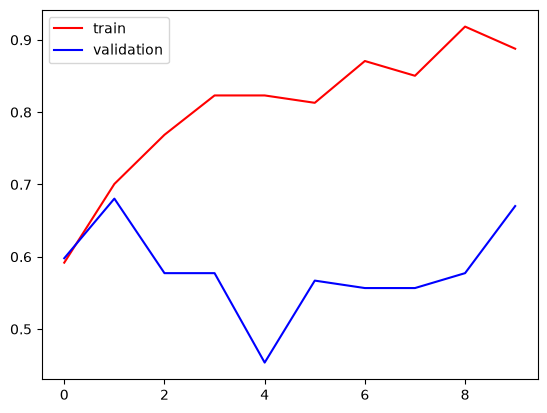

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()
     

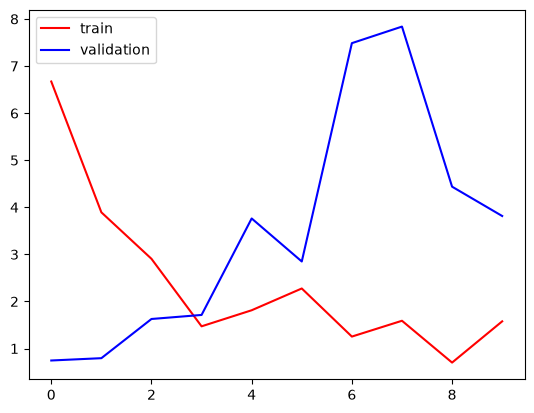

In [12]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()
     

# ways to reduce overfitting
Add more data
Data Augmentation
Dropout
Batch Norm
Reduce complexity

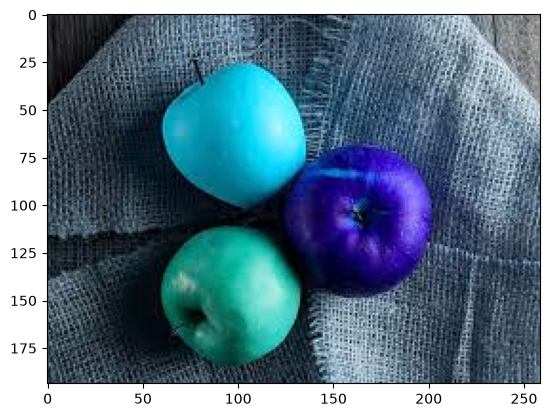

In [38]:

import cv2


test_img = cv2.imread("./test/apples/img_p3_88.jpeg")
plt.imshow(test_img)

In [39]:
test_img.shape

(194, 259, 3)

In [40]:
test_img = cv2.resize(test_img,(256,256))

In [41]:
test_img.shape

(256, 256, 3)

In [42]:
test_input = test_img.reshape((1,256,256,3))

In [43]:
result = model.predict(test_input)
result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


array([[1.]], dtype=float32)

In [44]:
if int(result[0][0]) == 0:
  print("Apple")

else:
  print("Tomato")
     

Tomato
